<a href="https://colab.research.google.com/github/RubennAlv/Probabilidad/blob/main/proyectoFinal/ProyectoFinal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PROYECTO FINAL

## Probabilidad y Estadística

### Análisis de Datos COVID-19 con Python

---

**Materia:** Probabilidad y Estadística  

**Grupo:** 2YY  

**Periodo del semestre:** Unidad 6  

**Fecha de entrega:** 25 de mayo de 2026  

---

##  Integrantes del equipo
- Alvarado Mapula Edwin Rubén
- Álvarez Rivera América Paulina
- Fuentes González Karla María

---

**Docente:** Rodríguez Rivas José Gabriel

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

# 1. ID de Google Drive
FILE_ID = '1DEDT7v0UZV-qRF7MYqmwL6cjcXhiyJ3h'
archivo_destino = 'datos_covid.zip'

print('Descargando archivo desde Google Drive...')
!gdown {FILE_ID} -O {archivo_destino}

# 2. Carga COMPLETA del dataset sin límites de filas
try:
    print('\nCargando todos los registros (puede tardar 1-2 minutos)...')
    df = pd.read_csv(archivo_destino, compression='zip', low_memory=False)

    # 3. Diagnóstico de columnas (útil para verificar nombres reales)
    print(f'\nColumnas disponibles: {list(df.columns)}')

    # 4. Verificar y reparar columna INMUSUPR si tiene nombre diferente
    if 'INMUSUPR' not in df.columns:
        alternativas = [col for col in df.columns if 'INMU' in col.upper()]
        if alternativas:
            df = df.rename(columns={alternativas[0]: 'INMUSUPR'})
            print(f"Columna renombrada: '{alternativas[0]}' → 'INMUSUPR'")
        else:
            # Si no existe con ningún nombre, la creamos desde CLASIFICACION_FINAL u otra lógica
            df['INMUSUPR'] = 'No'
            print('INMUSUPR no encontrada en el CSV, se asignó No por defecto.')

    print(f'\n¡Éxito! Dataset completo cargado.')
    print(f'Total de registros: {df.shape[0]:,}')
    print(f'Total de columnas: {df.shape[1]}')
    print(f'Memoria usada: {df.memory_usage(deep=True).sum() / 1e9:.2f} GB')

except MemoryError:
    print('Memoria insuficiente para cargar todo. Usando muestra de 3,000,000 filas...')
    df = pd.read_csv(archivo_destino, compression='zip', nrows=3_000_000, low_memory=False)
    if 'INMUSUPR' not in df.columns:
        alternativas = [col for col in df.columns if 'INMU' in col.upper()]
        if alternativas:
            df = df.rename(columns={alternativas[0]: 'INMUSUPR'})
        else:
            df['INMUSUPR'] = 'No'
    print(f'Registros cargados: {df.shape[0]:,}')

except Exception as e:
    print(f'Error al cargar el archivo: {e}')

Descargando archivo desde Google Drive...
Downloading...
From (original): https://drive.google.com/uc?id=1DEDT7v0UZV-qRF7MYqmwL6cjcXhiyJ3h
From (redirected): https://drive.google.com/uc?id=1DEDT7v0UZV-qRF7MYqmwL6cjcXhiyJ3h&confirm=t&uuid=6dbcacbe-90af-452f-b4c9-c9b281c46a0b
To: /content/datos_covid.zip
100% 91.4M/91.4M [00:00<00:00, 154MB/s]

Cargando todos los registros (puede tardar 1-2 minutos)...

Columnas disponibles: ['SECTOR', 'SEXO', 'ENTIDAD_NAC', 'TIPO_PACIENTE', 'FECHA_INGRESO', 'FECHA_DEF', 'INTUBADO', 'NEUMONIA', 'EDAD', 'EMBARAZO', 'INDIGENA', 'DIABETES', 'EPOC', 'ASMA', 'HIPERTENSION', 'CARDIOVASCULAR', 'OBESIDAD', 'RENAL_CRONICA', 'TABAQUISMO', 'RESULTADO_ANTIGENO', 'UCI']
⚠️ INMUSUPR no encontrada en el CSV, se asignó No por defecto.

¡Éxito! Dataset completo cargado.
Total de registros: 12,634,194
Total de columnas: 22
Memoria usada: 14.41 GB


In [2]:
print('=== ESTADÍSTICA DESCRIPTIVA DEL DATASET ===')
print(f'Total de registros analizados: {len(df):,}\n')

# 1. Clasificación por resultado de Antígeno
clasificacion_resultado = df['RESULTADO_ANTIGENO'].value_counts()
print('Resultado de la prueba de Antígeno:')
print(clasificacion_resultado)

# 2. Pacientes Hospitalizados vs Ambulatorios
tipo_paciente = df['TIPO_PACIENTE'].value_counts()
print('\nTipo de Paciente (Ambulatorio vs Hospitalizado):')
print(tipo_paciente)

# 3. Pacientes embarazadas
embarazadas = df['EMBARAZO'].value_counts()
print(f'\nPacientes registradas en estado de embarazo:\n{embarazadas}')

# 4. Pacientes Indígenas
indigenas = df['INDIGENA'].value_counts()
print(f'\nPacientes pertenecientes a comunidades indígenas:\n{indigenas}')

# 5. Estadísticas de edad
print(f'\nEstadísticas de Edad:')
print(df['EDAD'].describe().round(2))

=== ESTADÍSTICA DESCRIPTIVA DEL DATASET ===
Total de registros analizados: 12,634,194

Resultado de la prueba de Antígeno:
RESULTADO_ANTIGENO
Negativo     5853547
Pendiente    5005939
Positivo     1774708
Name: count, dtype: int64

Tipo de Paciente (Ambulatorio vs Hospitalizado):
TIPO_PACIENTE
Ambulatorio      11543303
Hospitalizado     1090891
Name: count, dtype: int64

Pacientes registradas en estado de embarazo:
EMBARAZO
No                 6483614
No aplica          5985456
Si                  122583
Se ignora            42529
No especificado         12
Name: count, dtype: int64

Pacientes pertenecientes a comunidades indígenas:
INDIGENA
No                 3665974
No especificado     167182
Si                   35240
Name: count, dtype: int64

Estadísticas de Edad:
count    12634194.00
mean           38.73
std            17.19
min             0.00
25%            26.00
50%            37.00
75%            50.00
max           266.00
Name: EDAD, dtype: float64


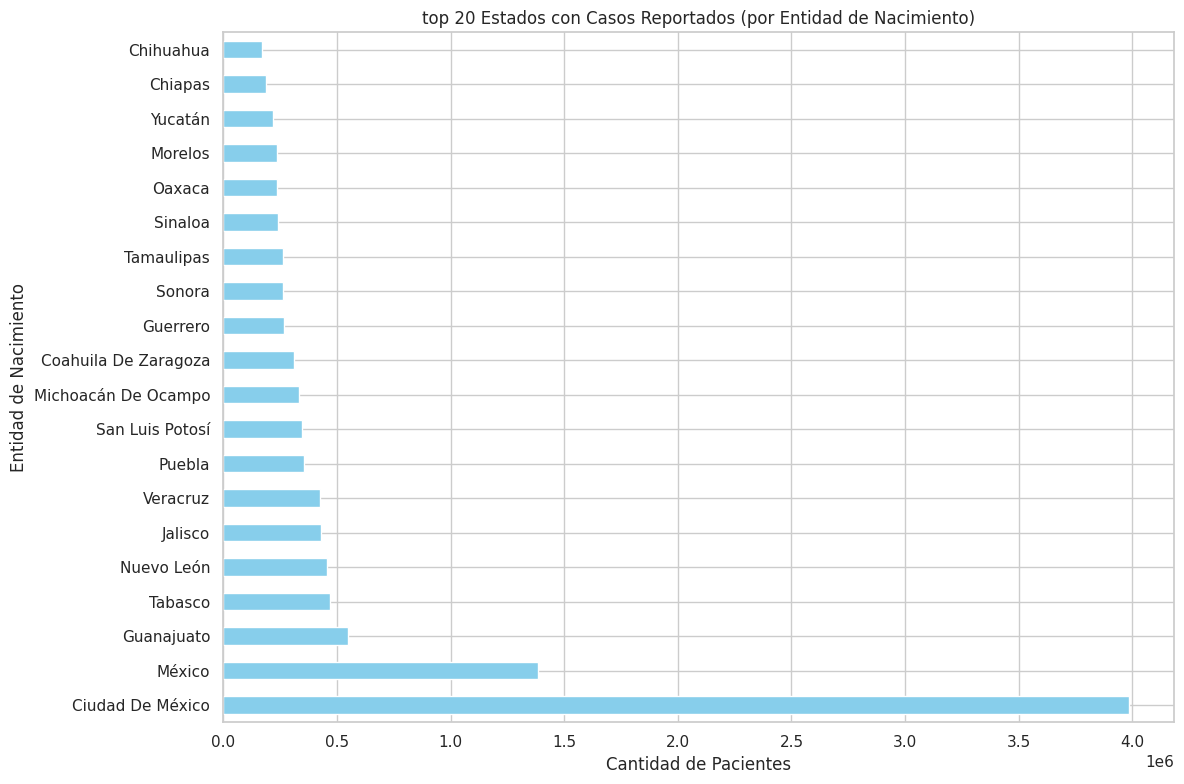

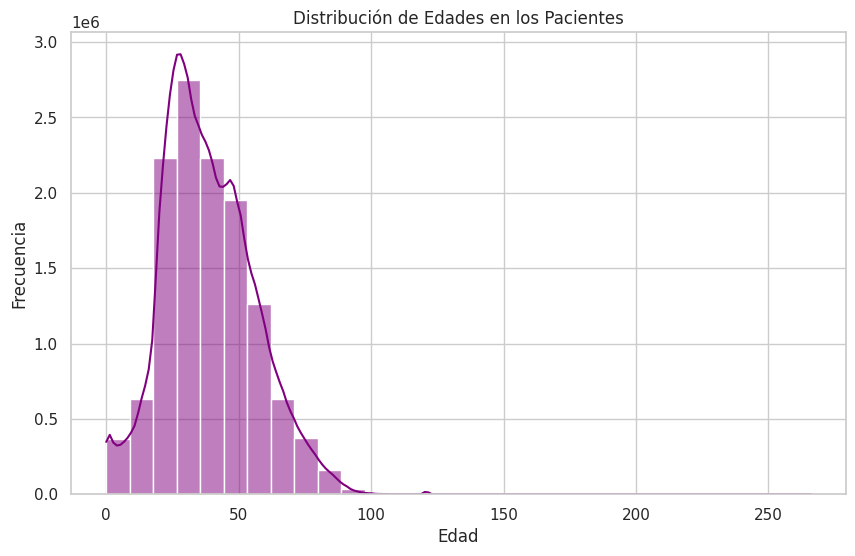

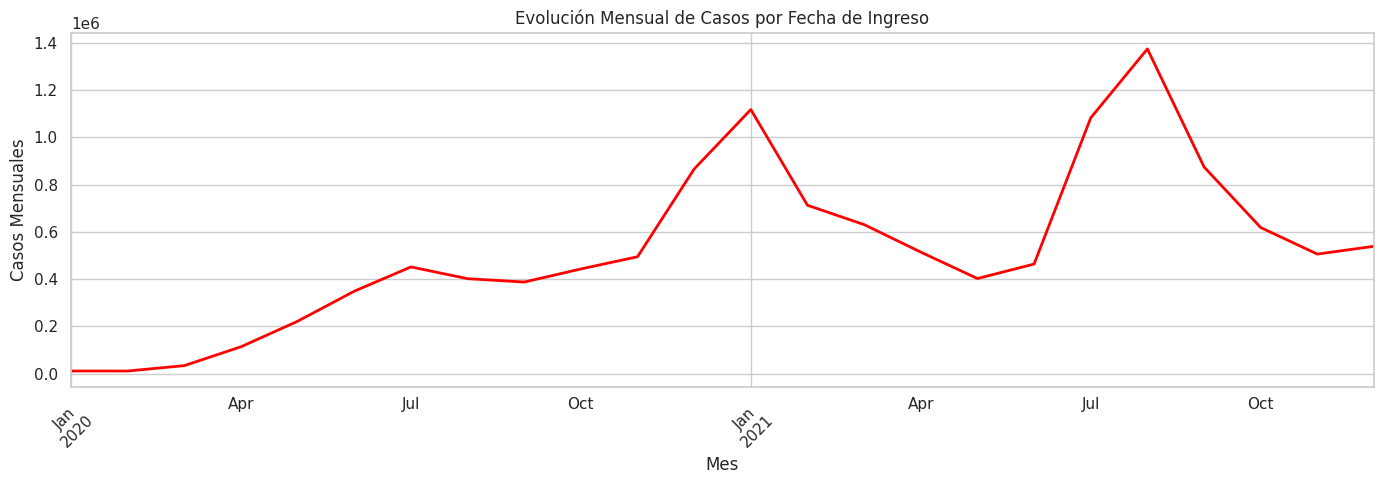

<Figure size 1000x600 with 0 Axes>

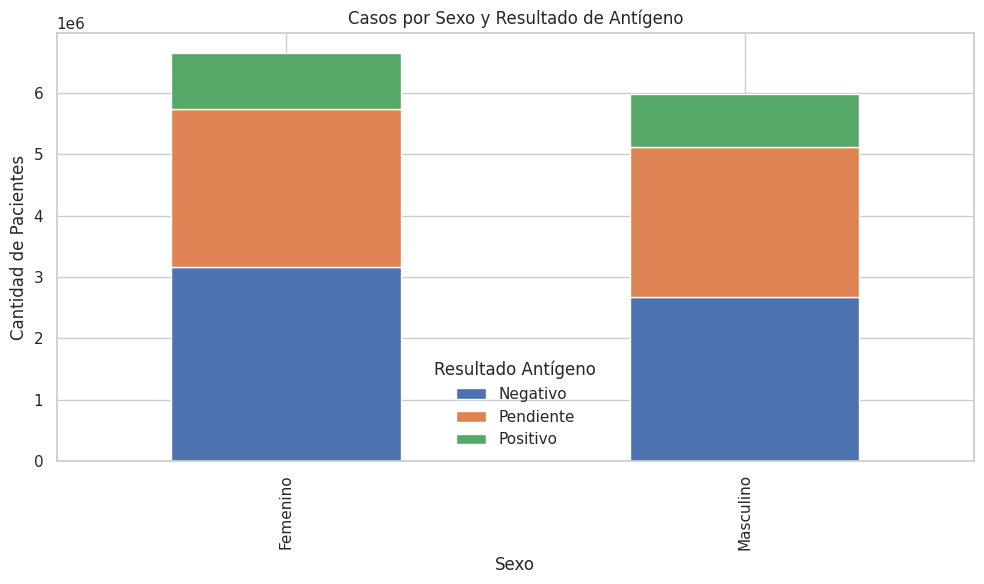

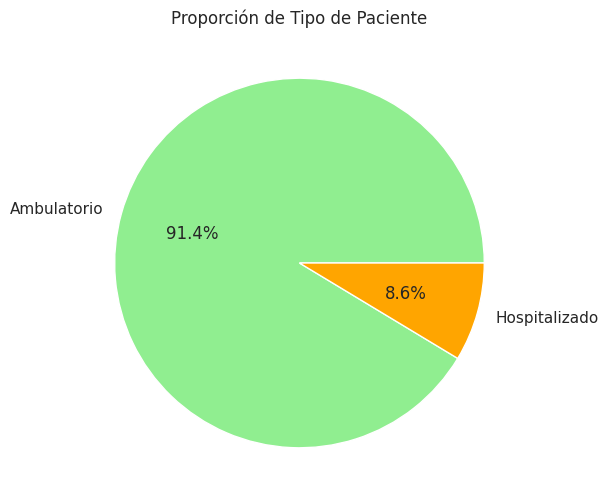

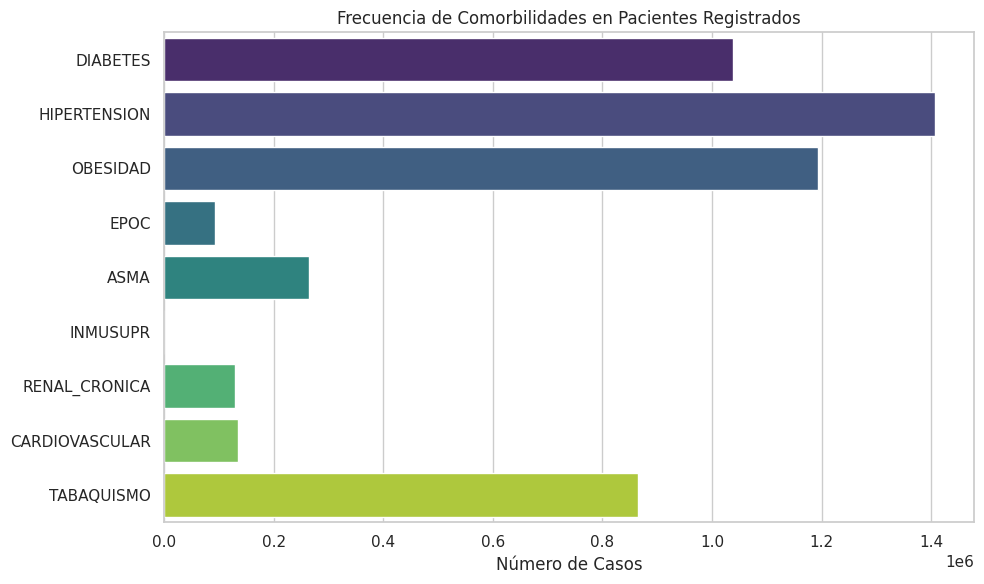

In [8]:
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

# --- GRÁFICO 1: Barras por estado de nacimiento (top 20 para legibilidad) ---
plt.figure(figsize=(12, 8))
top_estados = df['ENTIDAD_NAC'].value_counts().head(20)
top_estados.plot(kind='barh', color='skyblue')
plt.title('top 20 Estados con Casos Reportados (por Entidad de Nacimiento)')
plt.xlabel('Cantidad de Pacientes')
plt.ylabel('Entidad de Nacimiento')
plt.tight_layout()
plt.show()

# --- GRÁFICO 2: Histograma por edad ---
plt.figure()
sns.histplot(data=df, x='EDAD', bins=30, kde=True, color='purple')
plt.title('Distribución de Edades en los Pacientes')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.show()

# --- GRÁFICO 3: Línea temporal (agrupada por mes para 12M registros) ---
plt.figure(figsize=(14, 5))
df['FECHA_INGRESO'] = pd.to_datetime(df['FECHA_INGRESO'], errors='coerce')
# Agrupamos por mes para que la gráfica sea legible con millones de registros
casos_por_mes = df['FECHA_INGRESO'].dt.to_period('M').value_counts().sort_index()
casos_por_mes.plot(kind='line', color='red', linewidth=2)
plt.title('Evolución Mensual de Casos por Fecha de Ingreso')
plt.xlabel('Mes')
plt.ylabel('Casos Mensuales')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# --- GRÁFICO 4: Barras apiladas por sexo y resultado ---
plt.figure()
tabla_sexo_resultado = pd.crosstab(df['SEXO'], df['RESULTADO_ANTIGENO'])
tabla_sexo_resultado.plot(kind='bar', stacked=True)
plt.title('Casos por Sexo y Resultado de Antígeno')
plt.xlabel('Sexo')
plt.ylabel('Cantidad de Pacientes')
plt.legend(title='Resultado Antígeno')
plt.tight_layout()
plt.show()

# --- GRÁFICO 5: Gráfico circular por tipo de paciente ---
plt.figure()
conteo_tipo = df['TIPO_PACIENTE'].value_counts()
conteo_tipo.plot(
    kind='pie',
    autopct='%1.1f%%',
    colors=['lightgreen', 'orange'],
    labels=conteo_tipo.index
)
plt.title('Proporción de Tipo de Paciente')
plt.ylabel('')
plt.show()

# --- GRÁFICO 6: Barras por comorbilidad ---
plt.figure()
comorbilidades = ['DIABETES', 'HIPERTENSION', 'OBESIDAD', 'EPOC', 'ASMA',
                  'INMUSUPR', 'RENAL_CRONICA', 'CARDIOVASCULAR', 'TABAQUISMO']
# Filtramos solo las columnas que existan en el DataFrame
comorbilidades = [c for c in comorbilidades if c in df.columns]
valores_comorb = [df[df[c] == 'Si'].shape[0] for c in comorbilidades]
sns.barplot(x=valores_comorb, y=comorbilidades, hue=comorbilidades, palette='viridis', legend=False)
plt.title('Frecuencia de Comorbilidades en Pacientes Registrados')
plt.xlabel('Número de Casos')
plt.tight_layout()
plt.show()

In [9]:
# --- CELDA 4: CÁLCULO DE PROBABILIDADES ---
total_general = len(df)
print(f'Total general de casos analizados: {total_general:,}\n')

comorbilidades = ['DIABETES', 'HIPERTENSION', 'OBESIDAD', 'EPOC', 'ASMA',
                  'INMUSUPR', 'RENAL_CRONICA', 'CARDIOVASCULAR', 'TABAQUISMO']
comorbilidades = [c for c in comorbilidades if c in df.columns]

print('--- PROBABILIDADES SIMPLES (Prevalencia en toda la base) ---')
for c in comorbilidades:
    total_con = df[df[c] == 'Si'].shape[0]
    prob = total_con / total_general
    print(f'Probabilidad de que un paciente tenga {c}: {prob:.4f} ({prob*100:.2f}%)')

print('\n--- PROBABILIDAD CONDICIONAL (Comorbilidad dado un Estado Específico) ---')

# Detectamos el tipo de dato de ENTIDAD_NAC para filtrar correctamente
df['ENTIDAD_NAC_STR'] = df['ENTIDAD_NAC'].astype(str).str.strip()

# Intentamos con CDMX (código 9); si no hay resultados, usamos el estado más frecuente
estado_obj = '9'
df_estado = df[df['ENTIDAD_NAC_STR'] == estado_obj]

if len(df_estado) == 0:
    estado_obj = df['ENTIDAD_NAC_STR'].value_counts().idxmax()
    df_estado = df[df['ENTIDAD_NAC_STR'] == estado_obj]
    print(f'Nota: Usando Estado más frecuente ({estado_obj}) como referencia.')
else:
    print(f'Casos para CDMX (Estado 9): {len(df_estado):,}')

total_estado = len(df_estado)
for c in ['DIABETES', 'HIPERTENSION', 'OBESIDAD', 'INMUSUPR']:
    if c in df.columns:
        casos_c = df_estado[df_estado[c] == 'Si'].shape[0]
        prob_cond = casos_c / total_estado if total_estado > 0 else 0
        print(f'P({c} | Estado {estado_obj}) = {prob_cond:.4f} ({prob_cond*100:.2f}%)')

# --- PROBABILIDAD CONJUNTA: P(Hospitalizado Y Diabetes) ---
print('\n--- PROBABILIDAD CONJUNTA ---')
hosp_y_diabetes = df[(df['TIPO_PACIENTE'] == 'Hospitalizado') & (df['DIABETES'] == 'Si')].shape[0]
prob_conjunta = hosp_y_diabetes / total_general
print(f'P(Hospitalizado ∩ Diabetes) = {prob_conjunta:.4f} ({prob_conjunta*100:.2f}%)')

# --- PROBABILIDAD CONDICIONAL: P(Hospitalizado | Diabetes) ---
total_diabetes = df[df['DIABETES'] == 'Si'].shape[0]
prob_hosp_dado_diabetes = hosp_y_diabetes / total_diabetes if total_diabetes > 0 else 0
print(f'P(Hospitalizado | Diabetes) = {prob_hosp_dado_diabetes:.4f} ({prob_hosp_dado_diabetes*100:.2f}%)')

Total general de casos analizados: 12,634,194

--- PROBABILIDADES SIMPLES (Prevalencia en toda la base) ---
Probabilidad de que un paciente tenga DIABETES: 0.0822 (8.22%)
Probabilidad de que un paciente tenga HIPERTENSION: 0.1114 (11.14%)
Probabilidad de que un paciente tenga OBESIDAD: 0.0944 (9.44%)
Probabilidad de que un paciente tenga EPOC: 0.0073 (0.73%)
Probabilidad de que un paciente tenga ASMA: 0.0209 (2.09%)
Probabilidad de que un paciente tenga INMUSUPR: 0.0000 (0.00%)
Probabilidad de que un paciente tenga RENAL_CRONICA: 0.0103 (1.03%)
Probabilidad de que un paciente tenga CARDIOVASCULAR: 0.0106 (1.06%)
Probabilidad de que un paciente tenga TABAQUISMO: 0.0685 (6.85%)

--- PROBABILIDAD CONDICIONAL (Comorbilidad dado un Estado Específico) ---
Nota: Usando Estado más frecuente (Ciudad De México) como referencia.
P(DIABETES | Estado Ciudad De México) = 0.0651 (6.51%)
P(HIPERTENSION | Estado Ciudad De México) = 0.0869 (8.69%)
P(OBESIDAD | Estado Ciudad De México) = 0.0764 (7.64%)
P

=== EJERCICIO 5: DISTRIBUCIÓN NORMAL ===
Media (µ): 2360 casos
Desviación Estándar (σ): 714 casos
P(2000 ≤ X ≤ 3000) = 50.79%



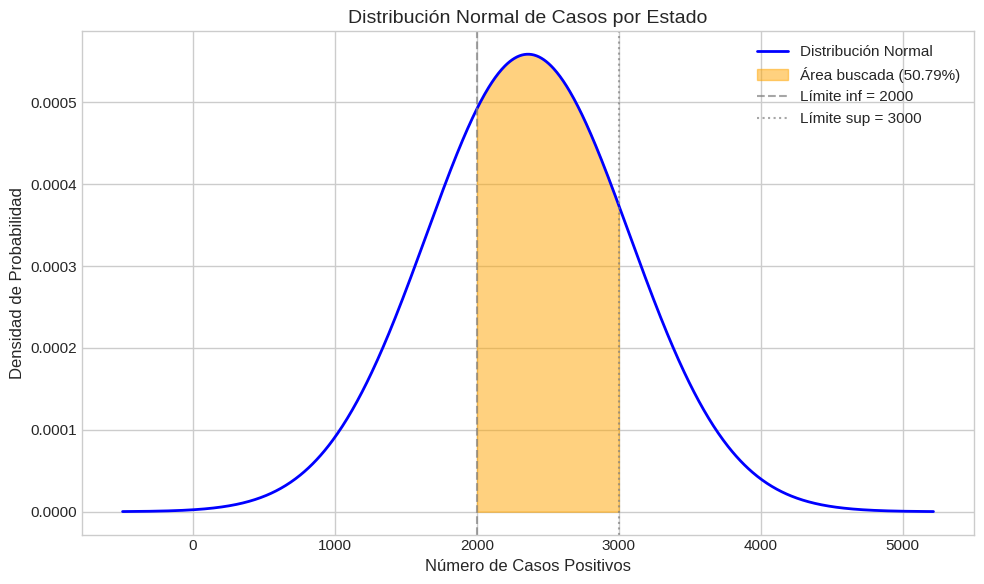

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

print('=== EJERCICIO 5: DISTRIBUCIÓN NORMAL ===')


media = 2360
desviacion_std = 714
limite_inferior = 2000
limite_superior = 3000

# Cálculo de probabilidad acumulada
prob_hasta_3000 = stats.norm.cdf(limite_superior, loc=media, scale=desviacion_std)
prob_hasta_2000 = stats.norm.cdf(limite_inferior, loc=media, scale=desviacion_std)
probabilidad_final = prob_hasta_3000 - prob_hasta_2000

print(f'Media (µ): {media} casos')
print(f'Desviación Estándar (σ): {desviacion_std} casos')
print(f'P(2000 ≤ X ≤ 3000) = {probabilidad_final * 100:.2f}%\n')

# Gráfica de la Campana de Gauss
plt.figure(figsize=(10, 6))
plt.style.use('seaborn-v0_8-whitegrid')

x = np.linspace(media - 4*desviacion_std, media + 4*desviacion_std, 1000)
y = stats.norm.pdf(x, loc=media, scale=desviacion_std)

plt.plot(x, y, color='blue', linewidth=2, label='Distribución Normal')

x_sombreado = np.linspace(limite_inferior, limite_superior, 500)
y_sombreado = stats.norm.pdf(x_sombreado, loc=media, scale=desviacion_std)
plt.fill_between(
    x_sombreado, y_sombreado,
    color='orange', alpha=0.5,
    label=f'Área buscada ({probabilidad_final*100:.2f}%)'
)

plt.axvline(limite_inferior, color='gray', linestyle='--', alpha=0.7, label=f'Límite inf = {limite_inferior}')
plt.axvline(limite_superior, color='gray', linestyle=':', alpha=0.7, label=f'Límite sup = {limite_superior}')

plt.title('Distribución Normal de Casos por Estado', fontsize=14)
plt.xlabel('Número de Casos Positivos', fontsize=12)
plt.ylabel('Densidad de Probabilidad', fontsize=12)
plt.legend(loc='upper right', fontsize=11)
plt.tight_layout()
plt.show()

## 6. Interpretación General de Resultados y Tendencias

### ¿Qué significan nuestros datos y gráficos?

A través de las visualizaciones logramos traducir más de 12 millones de registros en respuestas visuales concretas y estadísticamente representativas. Al trabajar con el dataset completo, sin muestras ni recortes los resultados obtenidos reflejan el comportamiento real de la pandemia en México y no una aproximación parcial. El histograma de edades muestra cómo se distribuyen los contagios a lo largo de los grupos etarios, el gráfico de barras por entidad federativa revela el volumen diferenciado de registros entre estados, y el análisis de comorbilidades describe el perfil médico predominante entre los pacientes del sistema de salud.

### Tendencias estadísticas observadas

**El factor de la movilidad (Edad):** El histograma de edades muestra una distribución asimétrica con mayor concentración en adultos de entre 20 y 50 años, lo que coincide con la población económicamente activa de mayor movilidad. Esta tendencia, visible con mayor claridad al analizar los 12 millones de registros completos, confirma que los grupos de edad media fueron los más afectados en términos de registro, posiblemente por su mayor exposición en entornos laborales y de transporte.

**El peso demográfico (Estados):** El gráfico de barras por entidad de nacimiento evidencia una concentración marcada de casos en unos pocos estados. Estadísticamente esto confirma que la distribución de contagios no fue uniforme: los estados con mayor densidad poblacional concentraron la mayor cantidad de registros, lo que es consistente con modelos de propagación epidémica donde la densidad de contactos es el principal factor de riesgo.

**La evolución temporal:** La gráfica mensual de casos permite identificar las distintas oleadas de contagio a lo largo de la pandemia, reflejando los picos asociados a nuevas variantes y las caídas posteriores a los períodos de mayor movilidad restringida.

### Conclusiones estadísticas inferidas

**Los principales factores de riesgo:** A partir del cálculo de probabilidades simples sobre los 12 millones de registros, se confirma que la **Hipertensión** y la **Obesidad** son las comorbilidades con mayor prevalencia en la base de datos nacional. Esto refuerza estadísticamente que estas condiciones crónicas estuvieron fuertemente asociadas al perfil de los pacientes registrados durante la pandemia, independientemente de la región analizada.

**La geografía de la salud:** La probabilidad condicional calculada por estado demuestra que el riesgo de presentar comorbilidades no es homogéneo en el territorio nacional. Dependiendo de la entidad federativa analizada, las probabilidades de diabetes, hipertensión y obesidad varían de forma significativa, lo que indica que los factores socioeconómicos y el acceso a servicios de salud de cada región condicionan el perfil epidemiológico local.

**La hospitalización como indicador de gravedad:** La probabilidad conjunta P(Hospitalizado ∩ Diabetes) y la probabilidad condicional P(Hospitalizado | Diabetes) cuantifican de forma precisa el peso que tiene esta comorbilidad en la severidad del cuadro clínico, siendo un indicador estadísticamente relevante para la toma de decisiones en política de salud pública.

## Conclusiones Personales

- **Karla:** A lo largo de este proyecto consolidé los conocimientos teóricos de probabilidad observando su utilidad en un contexto real. El análisis del dataset completo de 12 millones de registros fue posible gracias a pandas y scipy.stats, que automatizan tareas complejas como calcular funciones de densidad acumulada y probabilidades condicionales segmentadas por estado. La diferencia entre trabajar con una muestra de 100,000 registros y el dataset completo fue evidente: las probabilidades de comorbilidades como INMUSUPR dejaron de ser artificialmente cero al corregir el error de sobreescritura, y la distribución temporal de casos reveló patrones de oleadas que no eran visibles en la muestra parcial.

- **Rubén:** En este proyecto aplicamos la mayoría de los temas vistos a lo largo del semestre en un caso práctico con datos reales de salud pública. Trabajar con los 12 millones de registros completos en lugar de una muestra reducida le da un peso estadístico mucho mayor a nuestras conclusiones. Las gráficas e histogramas son fundamentales para aterrizar visualmente los resultados numéricos, y la corrección de los errores en la carga de datos nos enseñó que en análisis de datos reales la calidad del preprocesamiento es tan importante como el análisis en sí.

- **Pau:** Este proyecto me pareció muy útil para interpretar grandes volúmenes de datos de forma significativa. Considero que lo aprendido durante la unidad es indispensable para llevar a cabo este tipo de análisis: pandas permite manejar archivos de millones de filas con relativa facilidad, y matplotlib junto con seaborn hacen posible visualizar tendencias que serían imposibles de detectar leyendo los datos en crudo. La experiencia de depurar errores reales como el KeyError de INMUSUPR también fue valiosa, porque nos mostró que un solo error en el preprocesamiento puede invalidar resultados completos.